In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Since the notebook sits at the root, look directly downward into data/
df = pd.read_csv("data/regression_bonus_practice_data.csv")

print(df.head())


   index  number_of_siblings direct_admission     CCA learning_style  \
0      0                   0              Yes  Sports         Visual   
1      1                   2               No  Sports       Auditory   
2      2                   0              Yes     NaN         Visual   
3      3                   1               No   Clubs       Auditory   
4      4                   0               No  Sports       Auditory   

  student_id  gender tuition  final_test  n_male  n_female   age  \
0     ACN2BE  Female      No        69.0    14.0       2.0  16.0   
1     FGXIIZ  Female      No        47.0     4.0      19.0  16.0   
2     B9AI9F    Male      No        85.0    14.0       2.0  15.0   
3     FEVM1T  Female     Yes        64.0     2.0      20.0  15.0   
4     AXZN2E    Male      No        66.0    24.0       3.0  16.0   

   hours_per_week  attendance_rate sleep_time wake_time  mode_of_transport  \
0            10.0             91.0      22:00      6:00  private transport   
1 

This is the data analysis

In [65]:
#filtering out data without any values
df.isnull().sum()

index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64

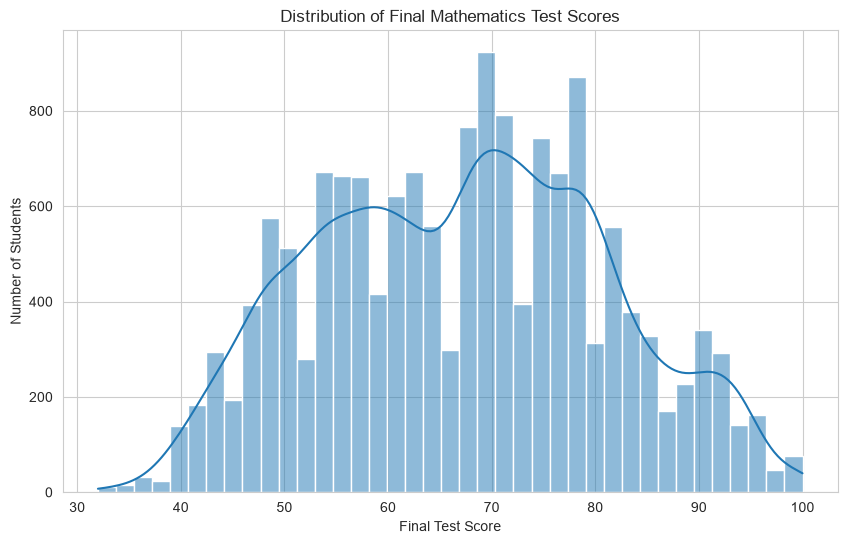

In [66]:
#Next, we use histogram of the final examination score

# Set the aesthetic style of the plots  
sns.set_style("whitegrid")  
  
# Histogram for resale price  
plt.figure(figsize=(10, 6))  
sns.histplot(df['final_test'], kde=True)  
plt.title('Distribution of Final Mathematics Test Scores')
plt.xlabel('Final Test Score')
plt.ylabel('Number of Students')
plt.show()

In [67]:
df['tuition'] = df['tuition'].replace({
    'Y': 'Yes',
    'N': 'No'
})
print(df['tuition'].value_counts())

tuition
Yes    8996
No     6904
Name: count, dtype: int64


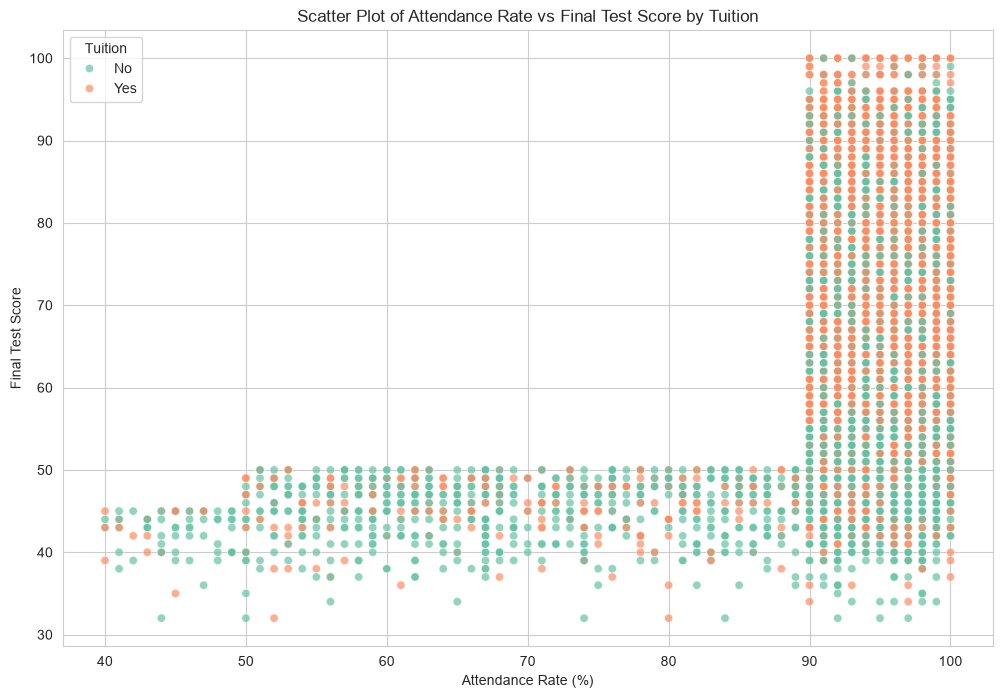

In [68]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='attendance_rate',
    y='final_test',
    hue='tuition',
    data=df,
    palette='Set2',
    alpha=0.7
)

plt.title('Scatter Plot of Attendance Rate vs Final Test Score by Tuition')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Final Test Score')
plt.legend(title='Tuition')
plt.show()

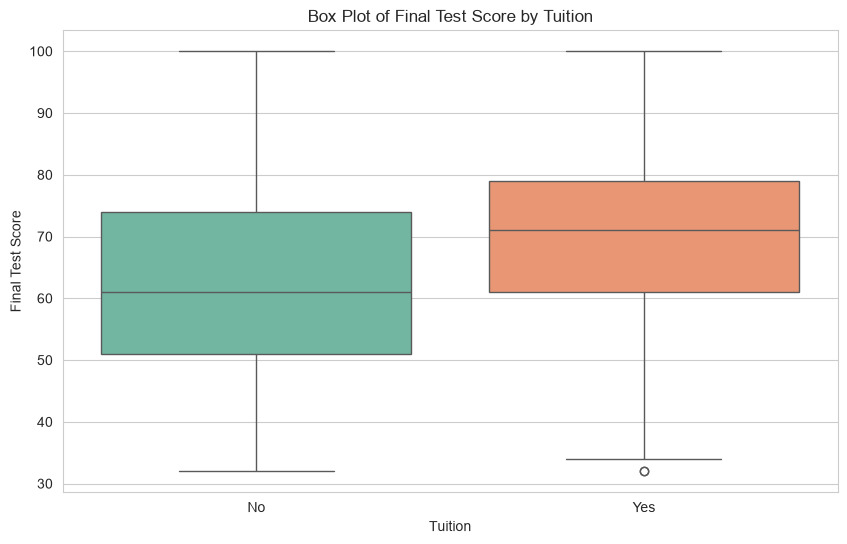

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='tuition',
    y='final_test',
    data=df,
    hue = 'tuition',
    palette='Set2'
)

plt.title('Box Plot of Final Test Score by Tuition')
plt.xlabel('Tuition')
plt.ylabel('Final Test Score')
plt.show()

Box Plot shows that students that attend tuition generally score higher in their Mathematics test scores.

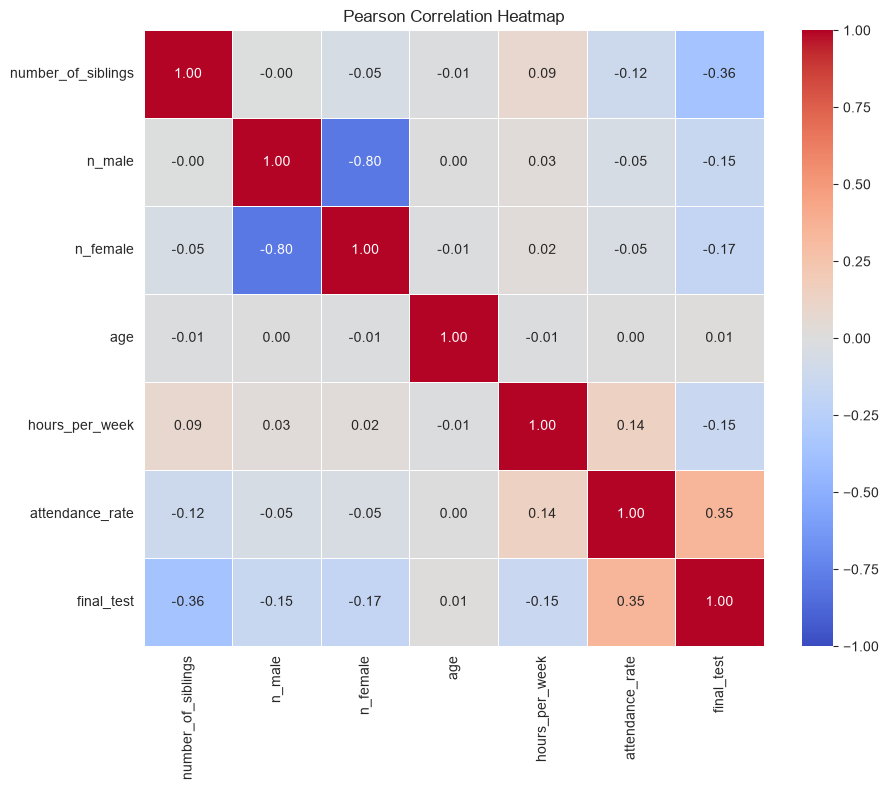

In [70]:
# Select continuous variables
continuous_vars_all = df[[
    'number_of_siblings',
    'n_male',
    'n_female',
    'age',
    'hours_per_week',
    'attendance_rate',
    'final_test'
]]

# Calculate the Pearson correlation matrix for the entire dataset
corr_matrix_pear = continuous_vars_all.corr(method='pearson')

# Plot the heatmap of the correlation matrix for the entire dataset
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix_pear,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    center=0,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title('Pearson Correlation Heatmap')
plt.show()

The Pearson Correlation Analysis shows a positive correlation with final test score with r = 0.35 for those with high attendance rate. 

In [71]:
categorical_cols = [
    'direct_admission',
    'CCA',
    'learning_style',
    'gender',
    'tuition',
    'sleep_time',
    'wake_time',
    'mode_of_transport',
    'bag_color'
]

for col in categorical_cols:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

direct_admission
direct_admission
No     11195
Yes     4705
Name: count, dtype: int64

CCA
CCA
Clubs     3912
Sports    3865
NaN       3829
Arts      3785
CLUBS      143
NONE       130
ARTS       128
SPORTS     108
Name: count, dtype: int64

learning_style
learning_style
Auditory    9132
Visual      6768
Name: count, dtype: int64

gender
gender
Male      7984
Female    7916
Name: count, dtype: int64

tuition
tuition
Yes    8996
No     6904
Name: count, dtype: int64

sleep_time
sleep_time
23:00    3131
22:00    3067
22:30    3034
21:00    2953
21:30    2875
0:00      240
23:30     183
1:00      122
0:30       93
2:00       81
1:30       73
2:30       25
3:00       23
Name: count, dtype: int64

wake_time
wake_time
5:00    3246
7:00    3206
6:00    3165
6:30    3158
5:30    3125
Name: count, dtype: int64

mode_of_transport
mode_of_transport
public transport     6371
private transport    6323
walk                 3206
Name: count, dtype: int64

bag_color
bag_color
yellow    2731
green     

In [72]:
df['CCA'] = df['CCA'].replace({
    'SPORTS': 'Sports'
})

In [73]:
df = df.dropna(subset=['final_test'])

In [74]:
df['attendance_rate'] = df['attendance_rate'].fillna(
    df['attendance_rate'].median()
)

In [75]:
df['CCA'] = df['CCA'].fillna('NIL')

In [76]:
df['student_id'].duplicated().sum()

np.int64(846)

In [77]:
df[df['student_id'].duplicated(keep=False)].sort_values('student_id')

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5534,5534,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,green
12290,12290,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,white
13541,13541,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
12270,12270,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
4303,4303,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7511,7511,0,No,NIL,Auditory,ZUGVXE,Female,No,67.0,24.0,3.0,16.0,9.0,91.0,21:30,5:30,public transport,red
9953,9953,1,No,Arts,Auditory,ZZICEC,Female,Yes,54.0,11.0,13.0,15.0,12.0,93.0,22:00,6:00,private transport,blue
4429,4429,1,No,Arts,Auditory,ZZICEC,Female,Yes,54.0,11.0,13.0,15.0,12.0,93.0,22:00,6:00,private transport,green
1241,1241,0,No,NIL,Visual,ZZNA57,Male,No,72.0,23.0,5.0,16.0,13.0,95.0,21:30,5:30,public transport,green


In [78]:
df = df.drop(columns=['index', 'student_id', 'bag_color']) 

In [79]:
df.info()

<class 'pandas.DataFrame'>
Index: 15405 entries, 0 to 15899
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   number_of_siblings  15405 non-null  int64  
 1   direct_admission    15405 non-null  str    
 2   CCA                 15405 non-null  str    
 3   learning_style      15405 non-null  str    
 4   gender              15405 non-null  str    
 5   tuition             15405 non-null  str    
 6   final_test          15405 non-null  float64
 7   n_male              15405 non-null  float64
 8   n_female            15405 non-null  float64
 9   age                 15405 non-null  float64
 10  hours_per_week      15405 non-null  float64
 11  attendance_rate     15405 non-null  float64
 12  sleep_time          15405 non-null  str    
 13  wake_time           15405 non-null  str    
 14  mode_of_transport   15405 non-null  str    
dtypes: float64(6), int64(1), str(8)
memory usage: 1.9 MB


In [80]:
categorical_columns = [
    'direct_admission',
    'CCA',
    'learning_style',
    'gender',
    'tuition',
    'sleep_time',
    'wake_time',
    'mode_of_transport'
]

for column in categorical_columns:
    print(column)
    print(df_cleaned[column].unique())
    print()

direct_admission
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

CCA
<StringArray>
['Sports', 'NIL', 'Clubs', 'Arts']
Length: 4, dtype: str

learning_style
<StringArray>
['Visual', 'Auditory']
Length: 2, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

tuition
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

sleep_time
<StringArray>
['22:00', '22:30', '21:00', '21:30', '23:00', '23:30',  '1:00',  '0:30',
  '1:30',  '2:30',  '0:00',  '2:00',  '3:00']
Length: 13, dtype: str

wake_time
<StringArray>
['6:00', '6:30', '5:00', '5:30', '7:00']
Length: 5, dtype: str

mode_of_transport
<StringArray>
['private transport', 'public transport', 'walk']
Length: 3, dtype: str



Next, Data Splitting

In [81]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop(columns=['final_test'])
y = df_cleaned['final_test']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Next, Feature Scalling

In [82]:
numerical_features = [
    'number_of_siblings',
    'n_male',
    'n_female',
    'age',
    'hours_per_week',
    'attendance_rate'
]

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a numerical transformer pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [84]:
categorical_features = [
    'direct_admission',
    'CCA',
    'learning_style',
    'gender',
    'tuition',
    'mode_of_transport'
]

In [85]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [86]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Next, Simple Linear Regression

In [87]:
# Select attendance rate as the single predictor
X_train_simple = X_train[['attendance_rate']]
X_test_simple = X_test[['attendance_rate']]

from sklearn.linear_model import LinearRegression

# Create Simple Linear Regression model
simple_model = LinearRegression()

# Train the model
simple_model.fit(X_train_simple, y_train)

y_pred_simple = simple_model.predict(X_test_simple)

print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_[0])

Intercept: 9.956492661871515
Coefficient: 0.6128195028191212


From the coefficient, we can see that for every 1% point increase in the attendance, the predicted final test score increase by 0.61 marks on average.

Visualisation using scatter plot

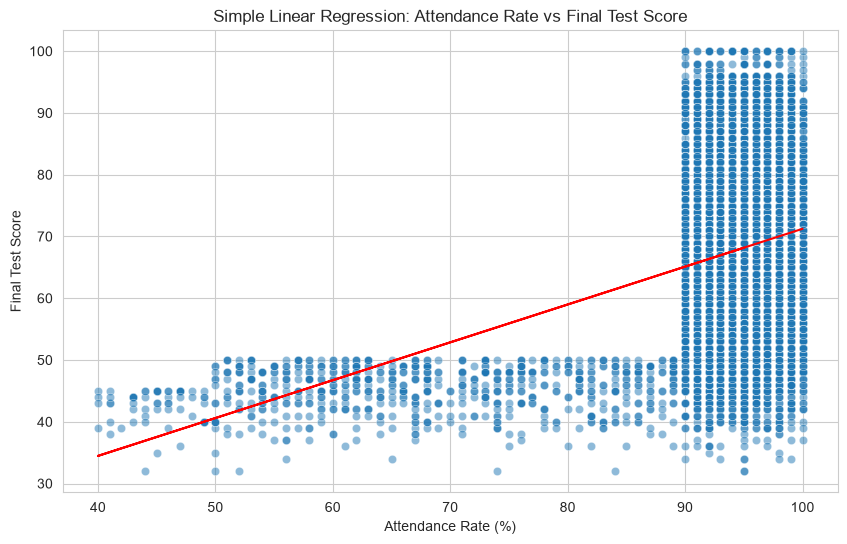

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_train_simple['attendance_rate'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train_simple['attendance_rate'],
    simple_model.predict(X_train_simple),
    color='red'
)

plt.title('Simple Linear Regression: Attendance Rate vs Final Test Score')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Final Test Score')
plt.show()

The regression line shows an overall positive relationship between their attendance and their examination performance. However, there is some variation among the 90% and the 100% attendance rates. Students with a similar attendance rates can achieve different examination scores as well. This means that, attendance rate alone is not enough to predict a student's Mathematical examination score.     

Next, Multivariate Linear Regression

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Create Multivariate Linear Regression pipeline
multi_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print(y_pred_multi[:10])

comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred_multi
})

comparison.head(10)

[66.09436823 74.93491866 79.48541619 73.98761917 54.53059131 62.6502383
 66.35425414 74.01188447 53.44328699 63.16995   ]


,Actual Score,Predicted Score
0,66.0,66.094368
1,57.0,74.934919
2,58.0,79.485416
3,88.0,73.987619
4,50.0,54.530591
5,72.0,62.650238
6,51.0,66.354254
7,83.0,74.011884
8,61.0,53.443287
9,93.0,63.169950


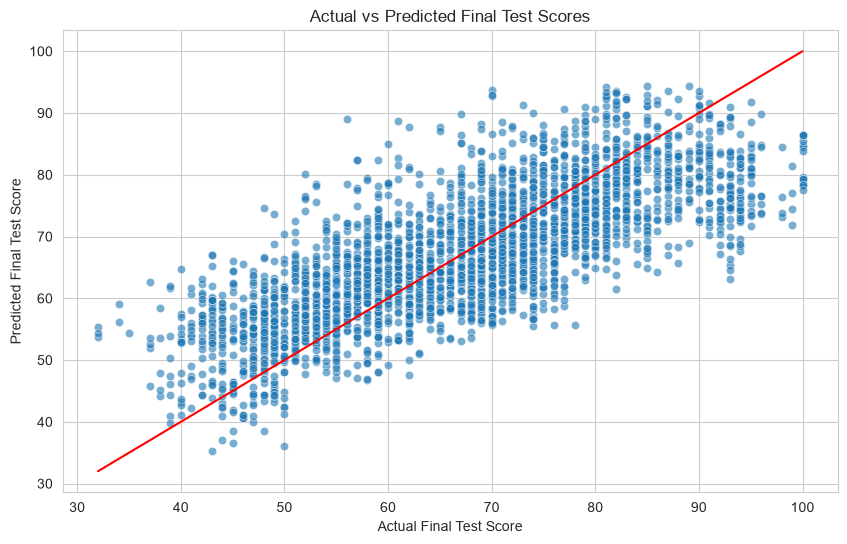

In [90]:
#Visualisation using scatter plot

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_multi,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title('Actual vs Predicted Final Test Scores')
plt.xlabel('Actual Final Test Score')
plt.ylabel('Predicted Final Test Score')
plt.show()

From the multivariate linear regression model where multiple student profiles are being used to predict the final Mathematics test score. The actual vs predicted shows a positive outcome. This shows that the model is able to capture different student with different variables. However, there are some obeservations where they are located relatively far from the reference line, underestimating some of the highest score and overestimating some of the lowest score. In conclusion, this model does not explain the examination performance either. 

Moving on to Model Evaluation

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Simple Linear Regression evaluation

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R²:", r2_simple)



Simple Linear Regression
MAE: 10.800246488935663
MSE: 172.69256720426162
RMSE: 13.141254399952146
R²: 0.11034236345139337


In [92]:
# Multivariate Linear Regression evaluation

mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multivariate Linear Regression")
print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

Multivariate Linear Regression
MAE: 7.239014211083308
MSE: 82.36012090043693
RMSE: 9.07524770463247
R²: 0.5757066346725082


In [93]:
evaluation_results = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multivariate Linear Regression'
    ],
    'MAE': [
        mae_simple,
        mae_multi
    ],
    'MSE': [
        mse_simple,
        mse_multi
    ],
    'RMSE': [
        rmse_simple,
        rmse_multi
    ],
    'R²': [
        r2_simple,
        r2_multi
    ]
})

evaluation_results

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,10.800246,172.692567,13.141254,0.110342
1,Multivariate Linear Regression,7.239014,82.360121,9.075248,0.575707


From this table, I can see that the multivariate linear regression table has performed better as compared to the simple linear regression. There is a decrease from 10.8(Simple) and 7.23 (Multivariate) in the MAE, shows that the multivariate's prediction differed from the actual examination score by 7.23 marks on average. Not only that, the R2 score also improved significantly from 0.11(Linear) to 0.57(Multivariate). This shows that using only the student's attendance rate is not enough to determine a student's performance in their Mathematics examination. 

In [94]:
#Bias-variance tradeoff

y_pred_multi = multi_model.predict(X_test)

y_train_pred_multi = multi_model.predict(X_train)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred_multi)
train_mse = mean_squared_error(y_train, y_train_pred_multi)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred_multi)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_pred_multi)
test_mse = mean_squared_error(y_test, y_pred_multi)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_multi)

bias_variance_results = pd.DataFrame({
    'Dataset': ['Training', 'Testing'],
    'MAE': [train_mae, test_mae],
    'MSE': [train_mse, test_mse],
    'RMSE': [train_rmse, test_rmse],
    'R²': [train_r2, test_r2]
})

bias_variance_results

,Dataset,MAE,MSE,RMSE,R²
0,Training,7.267534,82.749334,9.096666,0.577123
1,Testing,7.239014,82.360121,9.075248,0.575707


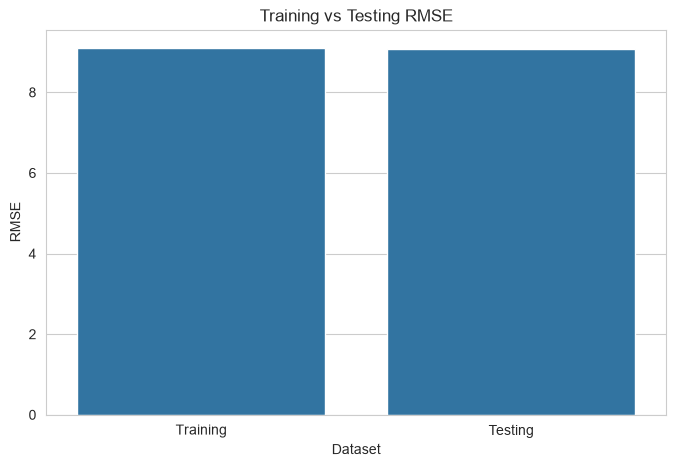

In [95]:
rmse_comparison = pd.DataFrame({
    'Dataset': ['Training', 'Testing'],
    'RMSE': [train_rmse, test_rmse]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rmse_comparison,
    x='Dataset',
    y='RMSE'
)

plt.title('Training vs Testing RMSE')
plt.ylabel('RMSE')
plt.show()

Overall, the model shows that it is relatively stable

In [96]:
#Ridge Pipeline

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Create Ridge Regression pipeline
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred_ridge
})

ridge_comparison.head(10)

,Actual Score,Predicted Score
0,66.0,66.094408
1,57.0,74.931602
2,58.0,79.481622
3,88.0,73.988304
4,50.0,54.534649
5,72.0,62.649757
6,51.0,66.353532
7,83.0,74.009265
8,61.0,53.445677
9,93.0,63.170046


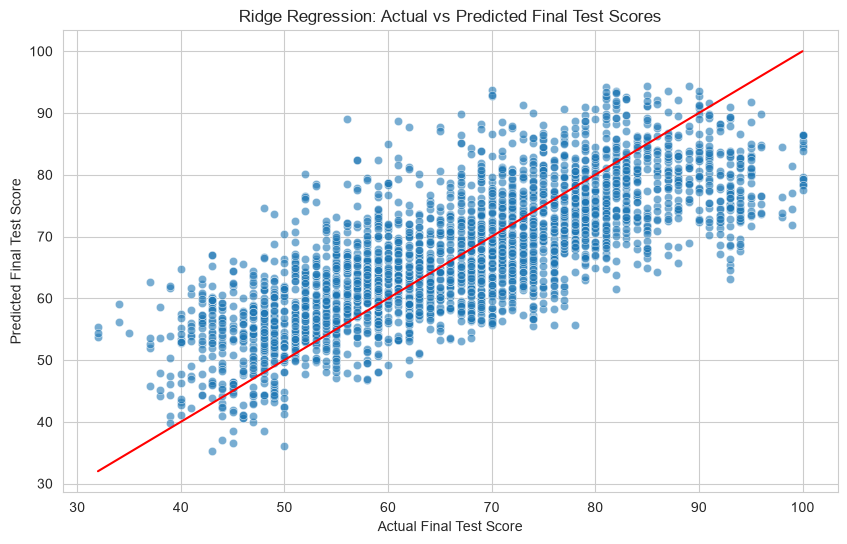

In [97]:
#Ridge scatterplot for visualisation
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_ridge,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title('Ridge Regression: Actual vs Predicted Final Test Scores')
plt.xlabel('Actual Final Test Score')
plt.ylabel('Predicted Final Test Score')
plt.show()

In [98]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression
MAE: 7.239056888903673
MSE: 82.35892392725012
RMSE: 9.075181757256992
R²: 0.5757128011008242


In [99]:
ridge_results = pd.DataFrame({
    'Model': [
        'Multivariate Linear Regression',
        'Ridge Regression'
    ],
    'MAE': [
        mae_multi,
        mae_ridge
    ],
    'MSE': [
        mse_multi,
        mse_ridge
    ],
    'RMSE': [
        rmse_multi,
        rmse_ridge
    ],
    'R²': [
        r2_multi,
        r2_ridge
    ]
})

ridge_results

,Model,MAE,MSE,RMSE,R²
0,Multivariate Linear Regression,7.239014,82.360121,9.075248,0.575707
1,Ridge Regression,7.239057,82.358924,9.075182,0.575713


In [100]:
#Lasso Regression model

from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

# Create Lasso Regression pipeline
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred_lasso
})

lasso_comparison.head(10)



,Actual Score,Predicted Score
0,66.0,64.992495
1,57.0,71.251245
2,58.0,74.147296
3,88.0,70.979656
4,50.0,60.751311
5,72.0,63.943812
6,51.0,66.840476
7,83.0,71.541800
8,61.0,60.330802
9,93.0,67.221572


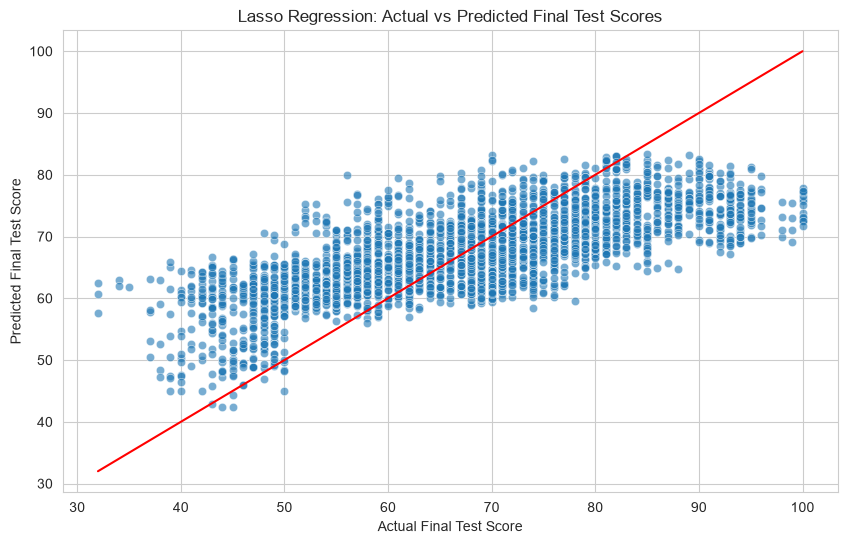

In [101]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lasso,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title('Lasso Regression: Actual vs Predicted Final Test Scores')
plt.xlabel('Actual Final Test Score')
plt.ylabel('Predicted Final Test Score')
plt.show()

In [102]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)

Lasso Regression
MAE: 8.211843734052595
MSE: 101.15122052957997
RMSE: 10.057396309660865
R²: 0.47890081636280013


In [103]:
lasso_coefficients = lasso_model.named_steps['regressor'].coef_

print("Number of coefficients:", len(lasso_coefficients))
print(
    "Number of coefficients reduced to zero:",
    np.sum(lasso_coefficients == 0)
)

Number of coefficients: 21
Number of coefficients reduced to zero: 11


In conclusion, Lasso Regression has shown a much worst prediction error and a lower R2 score. Despite reducing 14/24 model to coeeficient which made it into a simpler model, the reduction in predictive performances may suggest that some useful information regarding the student might have been omitted as well. Hence, lasso regression is unable to outperform the Multivariate linear regression. 

In [104]:
#GridSeacrh CV for ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameter values to test
ridge_param_grid = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_grid_search.fit(X_train, y_train)

print("Best Alpha:", ridge_grid_search.best_params_)
print("Best CV Score:", ridge_grid_search.best_score_)

Best Alpha: {'regressor__alpha': 1}
Best CV Score: -82.91856480407787


In [105]:

best_ridge_model = ridge_grid_search.best_estimator_

y_pred_ridge_tuned = best_ridge_model.predict(X_test)

mae_ridge_tuned = mean_absolute_error(y_test, y_pred_ridge_tuned)
mse_ridge_tuned = mean_squared_error(y_test, y_pred_ridge_tuned)
rmse_ridge_tuned = np.sqrt(mse_ridge_tuned)
r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)

print("Tuned Ridge Regression")
print("MAE:", mae_ridge_tuned)
print("MSE:", mse_ridge_tuned)
print("RMSE:", rmse_ridge_tuned)
print("R²:", r2_ridge_tuned)


Tuned Ridge Regression
MAE: 7.239056888903673
MSE: 82.35892392725012
RMSE: 9.075181757256992
R²: 0.5757128011008242


After using GridSearch CV on Ridge Regression, the tuned Ridge now have 7.23(MAE), 82.33(MSE) and 0.58(R2). Comparing to the original Ridge, the tuned Ridge does not show much improvement on the MAE, MSE and R2 as well. 

In [106]:
#GridSearch CV for lasso

from sklearn.model_selection import GridSearchCV

# Hyperparameter values to test
lasso_param_grid = {
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]
}

lasso_grid_search = GridSearchCV(
    estimator=lasso_model,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

lasso_grid_search.fit(X_train, y_train)

print("Best Alpha:", lasso_grid_search.best_params_)
print("Best CV Score:", lasso_grid_search.best_score_)


Best Alpha: {'regressor__alpha': 0.01}
Best CV Score: -82.913303867422


In [107]:
best_lasso_model = lasso_grid_search.best_estimator_

y_pred_lasso_tuned = best_lasso_model.predict(X_test)

mae_lasso_tuned = mean_absolute_error(
    y_test, y_pred_lasso_tuned
)

mse_lasso_tuned = mean_squared_error(
    y_test, y_pred_lasso_tuned
)

rmse_lasso_tuned = np.sqrt(mse_lasso_tuned)

r2_lasso_tuned = r2_score(
    y_test, y_pred_lasso_tuned
)

print("Tuned Lasso Regression")
print("MAE:", mae_lasso_tuned)
print("MSE:", mse_lasso_tuned)
print("RMSE:", rmse_lasso_tuned)
print("R²:", r2_lasso_tuned)

Tuned Lasso Regression
MAE: 7.240601049084744
MSE: 82.32315921877458
RMSE: 9.073211075400735
R²: 0.5758970495981933


In [108]:
lasso_tuned_coefficients = (
    best_lasso_model.named_steps['regressor'].coef_
)

print(
    "Number of coefficients:",
    len(lasso_tuned_coefficients)
)

print(
    "Number of coefficients reduced to zero:",
    np.sum(lasso_tuned_coefficients == 0)
)

Number of coefficients: 21
Number of coefficients reduced to zero: 3


After hypertuning the Lasso model, performance as been improved. The MAE has decreased from 8.23 to 7.24 (MAE) and an increased from 0.477 to 0.58 (R2). After tuning the alpha down to 0.01, only 4 coefficients were reduced. This means that the regularisation was too high and had removed information that is useful to determine the student's final examination score. 

In [109]:
final_results = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multivariate Linear Regression',
        'Tuned Ridge Regression',
        'Tuned Lasso Regression'
    ],
    'MAE': [
        mae_simple,
        mae_multi,
        mae_ridge_tuned,
        mae_lasso_tuned
    ],
    'MSE': [
        mse_simple,
        mse_multi,
        mse_ridge_tuned,
        mse_lasso_tuned
    ],
    'RMSE': [
        rmse_simple,
        rmse_multi,
        rmse_ridge_tuned,
        rmse_lasso_tuned
    ],
    'R²': [
        r2_simple,
        r2_multi,
        r2_ridge_tuned,
        r2_lasso_tuned
    ]
})

final_results.round(4)

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,10.8002,172.6926,13.1413,0.1103
1,Multivariate Linear Regression,7.2390,82.3601,9.0752,0.5757
2,Tuned Ridge Regression,7.2391,82.3589,9.0752,0.5757
3,Tuned Lasso Regression,7.2406,82.3232,9.0732,0.5759


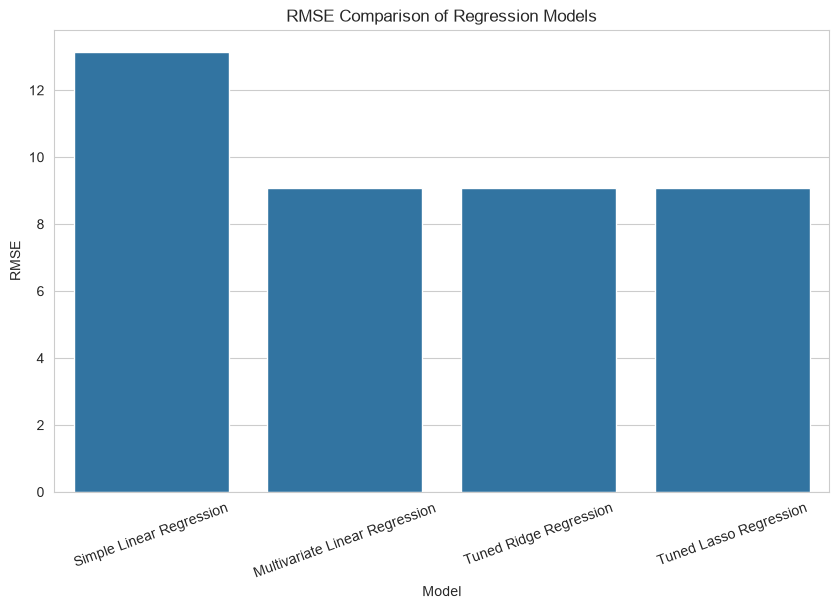

In [110]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results,
    x='Model',
    y='RMSE'
)

plt.title('RMSE Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.show()

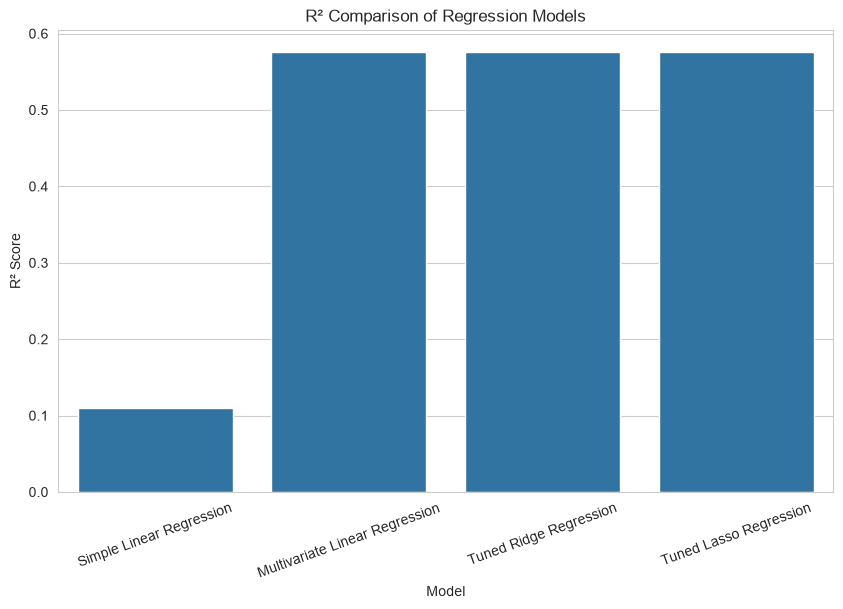

In [111]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results,
    x='Model',
    y='R²'
)

plt.title('R² Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=20)
plt.show()

Comparing all the models, I can see that the Multivariate Linear Regression has displayed the lowest MAE,7.24 and R2 with 0.58. Even though the tuned ridge shows a slightky better performance, I would still choose mutlivariate as the difference is insignificant. 